In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

# Load Data set

In [2]:
df = pd.read_csv("../data/raw/calendar.csv")
df.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [3]:
df.shape

(1969, 14)

In [4]:
df.columns.tolist()

['date',
 'wm_yr_wk',
 'weekday',
 'wday',
 'month',
 'year',
 'd',
 'event_name_1',
 'event_type_1',
 'event_name_2',
 'event_type_2',
 'snap_CA',
 'snap_TX',
 'snap_WI']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 263.1 KB


# Visualization

In [6]:
weekday_counts = df["weekday"].value_counts()

print(weekday_counts)

weekday
Saturday     282
Sunday       282
Monday       281
Tuesday      281
Wednesday    281
Thursday     281
Friday       281
Name: count, dtype: int64


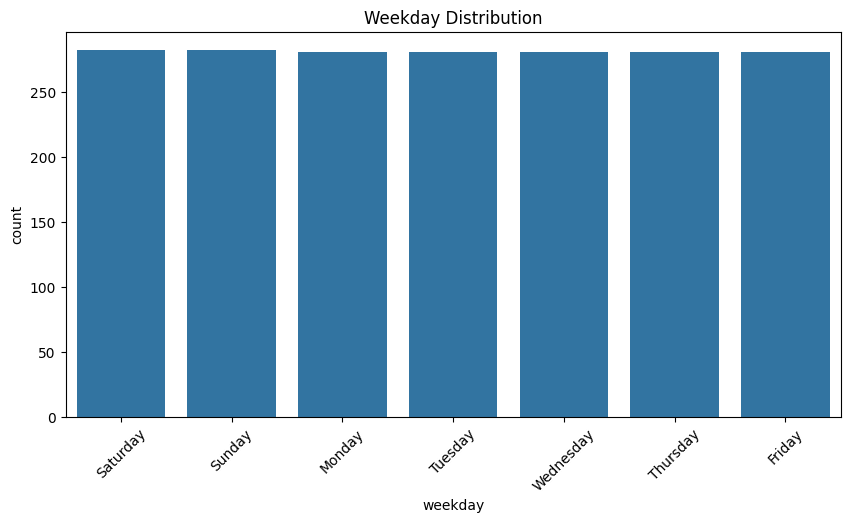

In [7]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="weekday",
    order=df["weekday"].value_counts().index
)

plt.title("Weekday Distribution")
plt.xticks(rotation=45)
plt.show()

# Event Count

In [8]:
event_counts = df["event_name_1"].value_counts()

print(event_counts)

event_name_1
SuperBowl              6
ValentinesDay          6
PresidentsDay          6
LentStart              6
LentWeek2              6
StPatricksDay          6
Purim End              6
Pesach End             6
Mother's day           6
MemorialDay            6
NBAFinalsStart         6
NBAFinalsEnd           6
Ramadan starts         6
OrthodoxEaster         5
Cinco De Mayo          5
IndependenceDay        5
Eid al-Fitr            5
LaborDay               5
ColumbusDay            5
Halloween              5
EidAlAdha              5
VeteransDay            5
Thanksgiving           5
Christmas              5
Chanukah End           5
NewYear                5
OrthodoxChristmas      5
MartinLutherKingDay    5
Easter                 5
Father's day           4
Name: count, dtype: int64


# Event Types

In [9]:
event_type_counts = df["event_type_1"].value_counts()

print(event_type_counts)

event_type_1
Religious    55
National     52
Cultural     37
Sporting     18
Name: count, dtype: int64


In [10]:
month_counts = df["month"].value_counts().sort_index()

print(month_counts)

month
1     158
2     170
3     186
4     180
5     186
6     169
7     155
8     155
9     150
10    155
11    150
12    155
Name: count, dtype: int64


# Month wise Cntribution

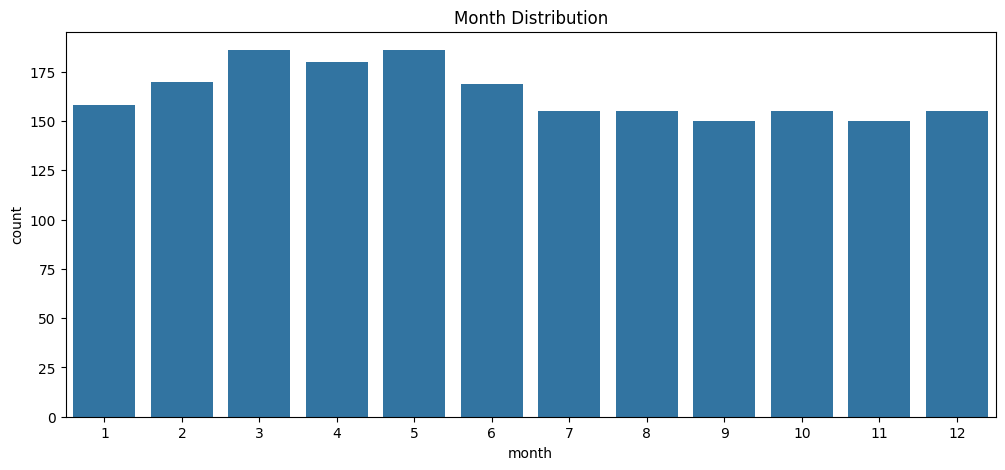

In [11]:
plt.figure(figsize=(12,5))

sns.countplot(data=df, x="month")

plt.title("Month Distribution")
plt.show()

# Holidays

In [12]:
holidays = df[df["event_type_1"] == "Religious"]

holidays[[
    "date",
    "event_name_1",
    "event_type_1"
]].head(20)


,date,event_name_1,event_type_1
39,2011-03-09,LentStart,Religious
46,2011-03-16,LentWeek2,Religious
50,2011-03-20,Purim End,Religious
85,2011-04-24,OrthodoxEaster,Religious
87,2011-04-26,Pesach End,Religious
184,2011-08-01,Ramadan starts,Religious
214,2011-08-31,Eid al-Fitr,Religious
282,2011-11-07,EidAlAdha,Religious
333,2011-12-28,Chanukah End,Religious
343,2012-01-07,OrthodoxChristmas,Religious


# National Events

In [13]:
national_events = df[df["event_type_1"] == "National"]

national_events[[
    "date",
    "event_name_1"
]].head(20)

,date,event_name_1
23,2011-02-21,PresidentsDay
121,2011-05-30,MemorialDay
156,2011-07-04,IndependenceDay
219,2011-09-05,LaborDay
254,2011-10-10,ColumbusDay
286,2011-11-11,VeteransDay
299,2011-11-24,Thanksgiving
330,2011-12-25,Christmas
337,2012-01-01,NewYear
352,2012-01-16,MartinLutherKingDay


# Sports Events

In [14]:
sports_events = df[df["event_type_1"] == "Sporting"]

sports_events[[
    "date",
    "event_name_1"
]].head(20)


,date,event_name_1
8,2011-02-06,SuperBowl
122,2011-05-31,NBAFinalsStart
134,2011-06-12,NBAFinalsEnd
372,2012-02-05,SuperBowl
500,2012-06-12,NBAFinalsStart
509,2012-06-21,NBAFinalsEnd
736,2013-02-03,SuperBowl
859,2013-06-06,NBAFinalsStart
873,2013-06-20,NBAFinalsEnd
1100,2014-02-02,SuperBowl


# Weekend Identification

In [15]:
df["is_weekend"] = df["weekday"].isin(["Saturday", "Sunday"])

df[["date", "weekday", "is_weekend"]].head(20)

,date,weekday,is_weekend
0,2011-01-29,Saturday,True
1,2011-01-30,Sunday,True
2,2011-01-31,Monday,False
3,2011-02-01,Tuesday,False
4,2011-02-02,Wednesday,False
5,2011-02-03,Thursday,False
6,2011-02-04,Friday,False
7,2011-02-05,Saturday,True
8,2011-02-06,Sunday,True
9,2011-02-07,Monday,False


# Weekend Counts

In [16]:
print(df["is_weekend"].value_counts())

is_weekend
False    1405
True      564
Name: count, dtype: int64


# Monthly Seasonality Preparation

In [17]:
monthly_days = df.groupby("month").size()

print(monthly_days)

month
1     158
2     170
3     186
4     180
5     186
6     169
7     155
8     155
9     150
10    155
11    150
12    155
dtype: int64


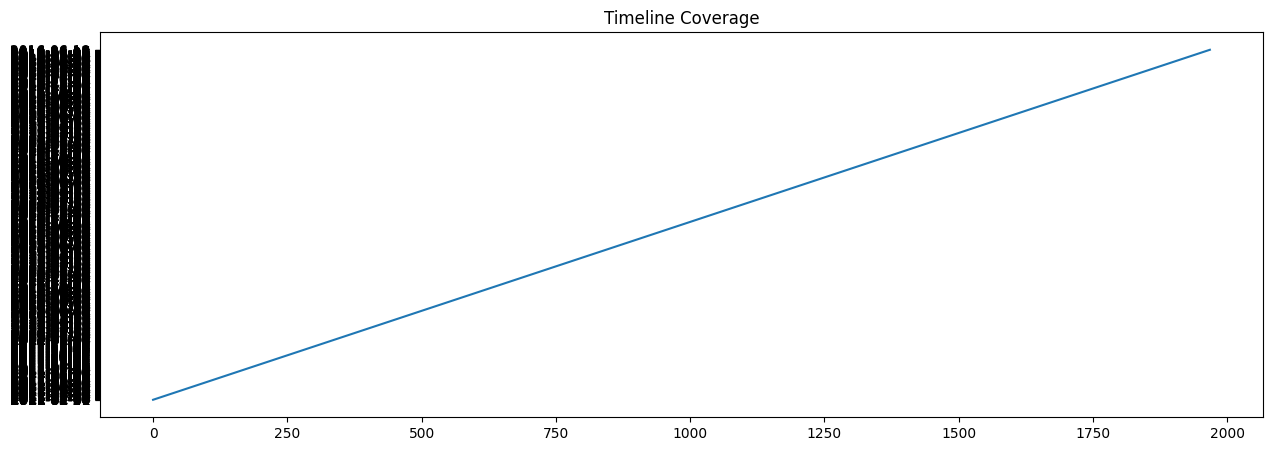

In [18]:
plt.figure(figsize=(15,5))

plt.plot(df["date"])

plt.title("Timeline Coverage")
plt.show()
